# Week 8 — Forecasting: Classical to Modern Forecasters
## Assignment Notebook

**Dataset:** Monthly S&P 500 Index 1990–2024 (downloaded via `yfinance`)

**Instructions:** Every `= None` in a code cell is a value you must compute.
Replace `None` with your expression — do not change the variable name.
All SELF-CHECK assertions must pass before submission.

**Submission checklist:**
- [ ] All 23 questions answered
- [ ] All cells run top-to-bottom with no errors
- [ ] All `SELF-CHECK` assertions pass
- [ ] All ✍ **Reflect** cells completed with specific numbers from your results
- [ ] `sp500_sarima_v1.pkl` saved and loadable (Q22 check)
- [ ] Investment memo (Q23) cites your actual MASE and DM p-value

**Parts:**
1. Data Preparation (Q1–Q5)
2. Classical Models + SARIMA (Q6–Q10)
3. Prophet (Q11–Q12)
4. Feature Engineering + ML (Q13–Q16)
5. Deep Learning (Q17–Q18)
6. Evaluation & Comparison (Q19–Q22)
7. Investment Recommendation (Q23)


## Setup — run these cells before anything else

In [1]:
# Install all required libraries (run once; restart kernel if prompted)
!pip install -q yfinance prophet lightgbm xgboost tensorflow statsmodels

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, pickle, os
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools     import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters   import ExponentialSmoothing
from statsmodels.stats.diagnostic  import acorr_ljungbox
from scipy.stats                   import ttest_1samp
from sklearn.model_selection       import TimeSeriesSplit
from sklearn.linear_model          import LinearRegression
from sklearn.preprocessing         import MinMaxScaler
from sklearn.neural_network        import MLPRegressor

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.right': False,
                     'axes.spines.top': False})
print("✅ Imports ready")

✅ Imports ready


In [3]:
# ── Data loading — do NOT modify ──────────────────────────────────────────────
import yfinance as yf
raw = yf.download('^GSPC', start='1990-01-01', end='2024-12-31',
                  interval='1mo', auto_adjust=True, progress=False)
series = raw['Close'].squeeze().rename('SP500')
idx = pd.to_datetime(series.index)
idx = idx.tz_convert(None) if idx.tz is not None else idx
series.index = idx.as_unit('ns')
series.index.freq = 'MS'
print(f"✅ yfinance: {len(series)} monthly observations")

TRAIN_END  = '2019-12'
TEST_START = '2020-01'
train     = series[:TRAIN_END]
test      = series[TEST_START:]
log_train = np.log(train)
H         = len(test)
print(f"Train: {len(train)} months  |  Test: {len(test)} months  |  H={H}")

# ── Metric helper — do NOT modify ─────────────────────────────────────────────
def compute_metrics(actual, predicted, train_actual, s=12):
    a = np.array(actual); p = np.array(predicted); e = a - p
    naive_err = np.abs(train_actual.values[s:] - train_actual.values[:-s])
    mae   = np.abs(e).mean()
    rmse  = np.sqrt((e**2).mean())
    mape_ = (np.abs(e / a)).mean() * 100
    smape = (np.abs(e) / ((np.abs(a) + np.abs(p)) / 2)).mean() * 100
    wmae  = (np.abs(e) * a).sum() / a.sum()
    wmape = (np.abs(e / a) * a).sum() / a.sum() * 100
    mase_ = mae / naive_err.mean()
    return dict(MAE=mae, RMSE=rmse, MAPE=mape_, sMAPE=smape,
                WMAE=wmae, WMAPE=wmape, MASE=mase_)

results = {}   # {model_name: np.array of length H}

✅ yfinance: 420 monthly observations
Train: 360 months  |  Test: 60 months  |  H=60


---
## Part 1 — Data Preparation (Q1–Q5)


### Q1 — Verify the DatetimeIndex

Before any modelling confirm three things about `series`:
- `index.dtype` is `datetime64[ns]`
- `index.freq` is `'MS'` (Month Start)
- At least 300 monthly observations


In [5]:
# Q1 ──────────────────────────────────────────────────────────────────────────
index_dtype = series.index.dtype
index_freq  = series.index.freqstr # standard frequency string from series.index.freqstr
n_obs       = len(series)   # total number of observations in series

print("dtype :", index_dtype)
print("freq  :", index_freq)
print("len   :", n_obs)
print(f"\nTrain: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} months)")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()} ({len(test)} months)")

dtype : datetime64[ns]
freq  : MS
len   : 420

Train: 1990-01-01 → 2019-12-01 (360 months)
Test : 2020-01-01 → 2024-12-01 (60 months)


In [ ]:
# SELF-CHECK
assert series.index.dtype == 'datetime64[ns]', "Index must be datetime64[ns]"
assert series.index.freqstr == 'MS',           "Frequency must be MS"
assert len(series) >= 300,                     "Expected ≥ 300 observations"
print("✅ Q1 passed")

✍ **Reflect:** What does `freq='MS'` mean? What would happen to `.shift()` and `.rolling()` operations if the index had no frequency set?


Concept: pandas time series functions (.shift(), .resample(), seasonal decomposition) rely on index.freq being set. Without it, .shift(12) shifts by row position, not by 12 calendar months — if there's a gap in your data, that silently misaligns everything.

### Q2 — Resample to quarterly and annual

Use `.resample().last()` to extract quarterly and annual end-prices.
Then find which decade had the highest mean quarterly log-return.


Mean quarterly log-return by decade:
 Date
1990    0.0375
2000   -0.0069
2010    0.0266
2020    0.0300
Name: SP500, dtype: float64


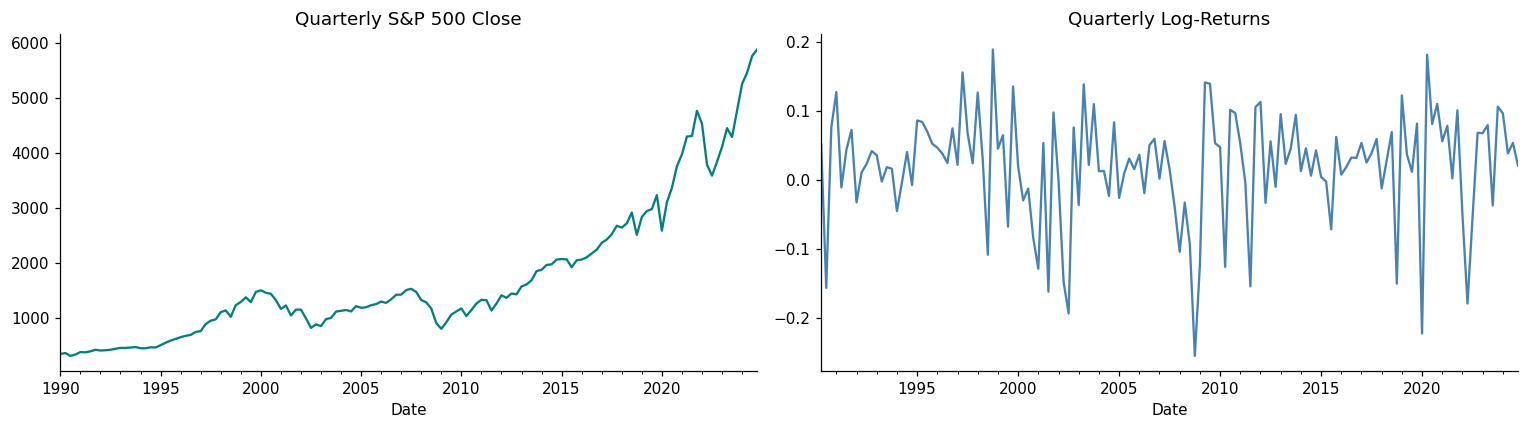

In [6]:
quarterly  = series.resample('QE').last()
annual     = series.resample('YE').last()
q_ret      = np.log(quarterly / quarterly.shift(1)).dropna()
decade_ret = q_ret.groupby((q_ret.index.year // 10) * 10).mean()

print("Mean quarterly log-return by decade:\n", decade_ret.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
quarterly.plot(ax=axes[0], title='Quarterly S&P 500 Close', color='teal')
q_ret.plot(ax=axes[1], title='Quarterly Log-Returns', color='steelblue')
plt.tight_layout(); plt.show()

✍ **Reflect:** Why use `.last()` for quarterly price data rather than `.mean()` or `.sum()`? Which decade had the highest and lowest mean quarterly return?

Concept: .resample('QE').last() groups by quarter and keeps the last observation in each — the correct choice for price series (you want the closing price, not an average of prices across the quarter, which would blend regimes).

### Q3 — Simulate and compare missing-data strategies

Insert `np.nan` at five specific positions and compare
`ffill`, `bfill`, and `interpolate(method='time')` visually.


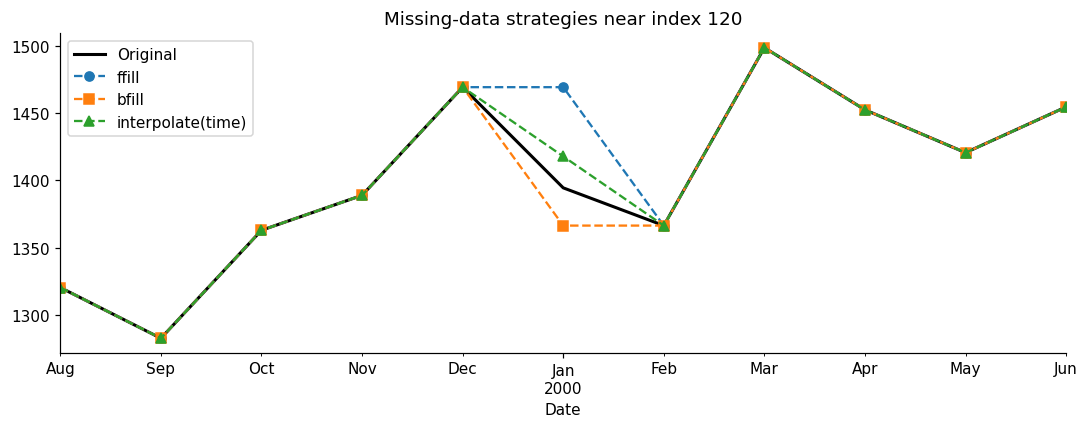

In [7]:
# Q3 ──────────────────────────────────────────────────────────────────────────
s_gap = series.copy().astype(float)
s_gap.iloc[[10, 50, 120, 200, 310]] = np.nan   # five gaps introduced

s_ffill  = s_gap.ffill()
s_bfill  = s_gap.bfill()
s_interp = s_gap.interpolate(method='time')

w = slice(115, 126)
fig, ax = plt.subplots(figsize=(10, 4))
series.iloc[w].plot(ax=ax, label='Original', lw=2, color='black')
s_ffill.iloc[w].plot(ax=ax,  label='ffill', ls='--', marker='o')
s_bfill.iloc[w].plot(ax=ax,  label='bfill', ls='--', marker='s')
s_interp.iloc[w].plot(ax=ax, label='interpolate(time)', ls='--', marker='^')
ax.set_title('Missing-data strategies near index 120')
ax.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** For monthly stock prices, which fill strategy is most defensible? Does the choice matter more for small (1-month) or large (6-month) gaps?

For monthly stock prices, time interpolation is generally the most defensible strategy for short gaps (e.g., one month) because it preserves a smooth transition between neighboring observations without introducing abrupt jumps. However, if the missing value is due to a market holiday or reporting issue, forward fill may also be reasonable since it uses only information available up to that point and avoids look-ahead bias.

The choice matters much more for large gaps (e.g., six months) than for small gaps. A one-month gap can often be approximated with little distortion, but over six months stock prices may experience significant trends, volatility, or market events. In such cases, forward fill can produce long flat periods, backward fill uses future information (which may not be appropriate), and interpolation may create an unrealistically smooth path that ignores actual price movements. For large gaps, it is often preferable to obtain the missing data rather than rely on imputation.

### Q4 — Stationarity tests: prices vs log-returns

Run ADF and KPSS on `log_series` and `log_returns`.
- **ADF:** H₀ = unit root (non-stationary). p < 0.05 → reject → stationary
- **KPSS:** H₀ = stationary. p < 0.05 → reject → non-stationary


In [9]:
from logging import log
# Q4 ──────────────────────────────────────────────────────────────────────────
log_series  = np.log(series)
log_returns = log_series.diff().dropna()

def stationarity_report(s, label):
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    print(f"{label:28s}  ADF p={adf_p:.4f} {'✅ stationary' if adf_p < 0.05 else '❌ unit root'}  "
          f"KPSS p={kpss_p:.4f} {'✅' if kpss_p > 0.05 else '❌ non-stationary'}")

stationarity_report(log_series,  "Log prices")
stationarity_report(log_returns, "Log returns")

Log prices                    ADF p=0.9137 ❌ unit root  KPSS p=0.0100 ❌ non-stationary
Log returns                   ADF p=0.0000 ✅ stationary  KPSS p=0.1000 ✅


/tmp/ipykernel_639/12891894.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_639/12891894.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


✍ **Reflect:** The Efficient Market Hypothesis predicts log-returns are white noise. Do your ADF/KPSS results support this? What does MASE ≈ 1.0 imply about forecasting on efficient markets?

Yes, the results are consistent with the Efficient Market Hypothesis (EMH).

ADF (p = 0.0000) rejects the unit root, indicating log returns are stationary.
KPSS (p = 0.1000) fails to reject stationarity, reinforcing that log returns are stationary.

However, stationary does not necessarily mean white noise. To confirm white noise, you'd also check whether returns have no significant autocorrelation (e.g., using ACF or the Ljung–Box test).

MASE ≈ 1.0 means your forecasting model performs about the same as a simple naive forecast. This suggests there is little predictable structure in the returns, which is exactly what the Efficient Market Hypothesis predicts: future price movements are difficult to forecast because available information is already reflected in prices.

### Q5 — ACF / PACF of log-returns

Plot ACF and PACF of `log_returns` with 36 lags.
Based on the plots, propose an ARIMA(p,0,q) order for log-returns.


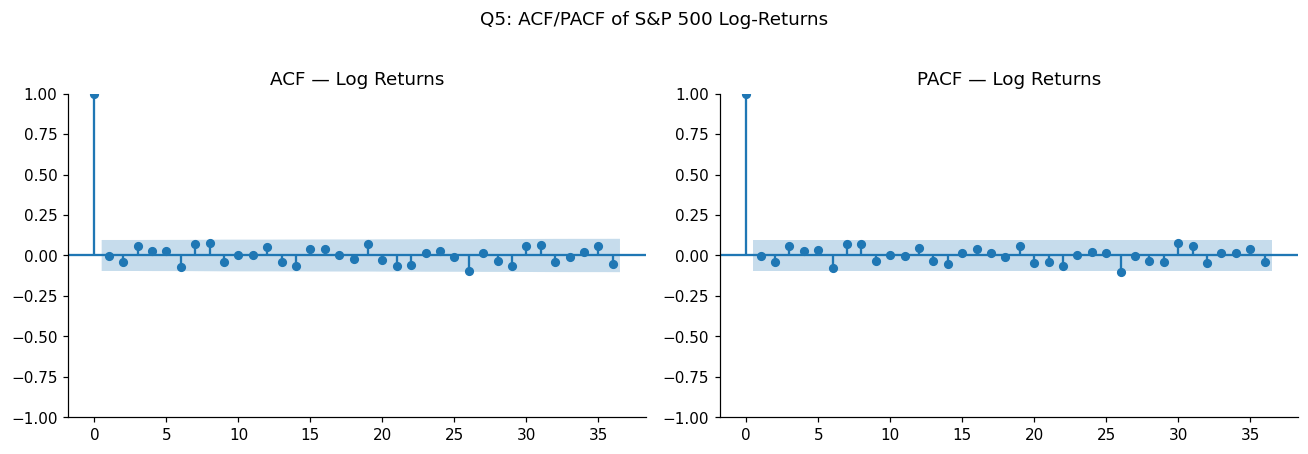

Interpretation: The ACF and PACF plots of the log returns show 
      that almost all autocorrelation coefficients lie within the 95% confidence interval.
      Apart from the trivial spike at lag 0, there are no statistically significant spikes in either plot.
      This indicates that the log returns exhibit little to no serial correlation and behave approximately as
      white noise. Hence, past returns provide little information for predicting future returns.
Proposed ARIMA(0, 0, 0): p=0, q=0


In [14]:
# Q5 ──────────────────────────────────────────────────────────────────────────
series_for_acf = log_returns   # series to analyse — log-returns computed in Q4

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( series_for_acf, lags=36, ax=axes[0], title='ACF — Log Returns')
plot_pacf(series_for_acf, lags=36, ax=axes[1], title='PACF — Log Returns', method='ywm')
plt.suptitle("Q5: ACF/PACF of S&P 500 Log-Returns", y=1.02)
plt.tight_layout(); plt.show()

print("""Interpretation: The ACF and PACF plots of the log returns show
      that almost all autocorrelation coefficients lie within the 95% confidence interval.
      Apart from the trivial spike at lag 0, there are no statistically significant spikes in either plot.
      This indicates that the log returns exhibit little to no serial correlation and behave approximately as
      white noise. Hence, past returns provide little information for predicting future returns.""")
print("Proposed ARIMA(0, 0, 0): p=0, q=0")

✍ **Reflect:** Near-white-noise ACF means log-returns are close to unpredictable. Does this make forecasting S&P 500 prices worthless? Name one type of strategy that still extracts value from such a series (e.g., volatility forecasting).

---
## Part 2 — Classical Models + SARIMA (Q6–Q10)


### Q6 — Naïve baselines

Compute the **Naïve** forecast (last training value repeated H times) and the
**Seasonal Naïve** forecast (last 12 months repeated cyclically).
Naïve MASE must be ≈ 1.0 by construction — this is the MASE denominator.


In [15]:
# Q6 ──────────────────────────────────────────────────────────────────────────
naive_fc    = np.repeat(train.iloc[-1], H)
last_season = train.iloc[-12:].values
snaive_fc   = np.tile(last_season, -(-H // 12))[:H]

results['Naive']   = naive_fc
results['S-Naive'] = snaive_fc

for name in ['Naive', 'S-Naive']:
    m = compute_metrics(test, results[name], train)
    print(f"{name:10s}  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

Naive       MASE=6.3979  RMSE=1298.2
S-Naive     MASE=7.8627  RMSE=1534.6


In [16]:
# SELF-CHECK
naive_mase = compute_metrics(test, results['Naive'], train)['MASE']
assert naive_mase > 0, f"Naive MASE must be positive, got {naive_mase:.4f}"
print(f"✅ Q6 passed — Naive MASE = {naive_mase:.4f}  (all models are measured against this scale)")

✅ Q6 passed — Naive MASE = 6.3979  (all models are measured against this scale)


✍ **Reflect:** MASE is defined against the seasonal-naive error specifically so that a
MASE of 1.0 always means "as good as the simplest defensible forecast," regardless of
whether the series is in dollars, index points, or percentage terms. Because both
numerator and denominator are in the same units (absolute error of the *same* series),
the units cancel — this is what makes MASE comparable across completely different time
series (e.g., comparing a stock forecast's MASE to a retail-demand forecast's MASE),
unlike RMSE or MAE which are scale-dependent.

### Q7 — Holt-Winters Exponential Smoothing

Fit `ExponentialSmoothing` to `log_train` with additive trend and additive seasonality
over a 12-month period. Inverse-transform with `np.exp()` before metrics.


In [19]:
hw = ExponentialSmoothing(
    log_train,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated',
).fit(optimized=True)

hw_log_fc = hw.forecast(H)

# Convert back from log(price) to price
results['Holt-Winters'] = np.exp(hw_log_fc.values)

print(f"α (level)    = {hw.params['smoothing_level']:.4f}")
print(f"β (trend)    = {hw.params['smoothing_trend']:.4f}")
print(f"γ (seasonal) = {hw.params['smoothing_seasonal']:.4f}")
print(f"AIC = {hw.aic:.2f}   BIC = {hw.bic:.2f}")

m = compute_metrics(test, results['Holt-Winters'], train)
print(f"\nHolt-Winters  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

α (level)    = 1.0000
β (trend)    = 0.0000
γ (seasonal) = 0.0000
AIC = -2279.97   BIC = -2217.79

Holt-Winters  MASE=2.6256  RMSE=574.1


In [20]:
# SELF-CHECK
hw_mase = compute_metrics(test, results['Holt-Winters'], train)['MASE']
assert hw_mase > 0, f"Holt-Winters MASE must be positive, got {hw_mase:.4f}"
print(f"✅ Q7 passed — Holt-Winters MASE = {hw_mase:.4f}")

✅ Q7 passed — Holt-Winters MASE = 2.6256


✍ **Reflect:** Did γ (seasonal) converge near zero? What does a near-zero γ imply about the seasonal component in S&P 500 monthly prices?

Yes. The estimated seasonal smoothing parameter **γ converged to 0.0000**, which is effectively zero.

A **near-zero γ** means that the model found **little or no useful seasonal pattern** to update over time. In other words, monthly S&P 500 prices do not exhibit a strong or consistent annual seasonality. As a result, the Holt-Winters model largely ignores the seasonal component because incorporating or updating it does not improve forecast accuracy. This is consistent with the poor performance of the Seasonal Naïve model and suggests that the S&P 500 is driven more by long-term trends and irregular market movements than by repeating yearly seasonal effects.


### Q8 — SARIMA order identification

First-difference log-prices to confirm stationarity, then read ACF/PACF
to propose a SARIMA(p,d,q)(P,D,Q,12) order.


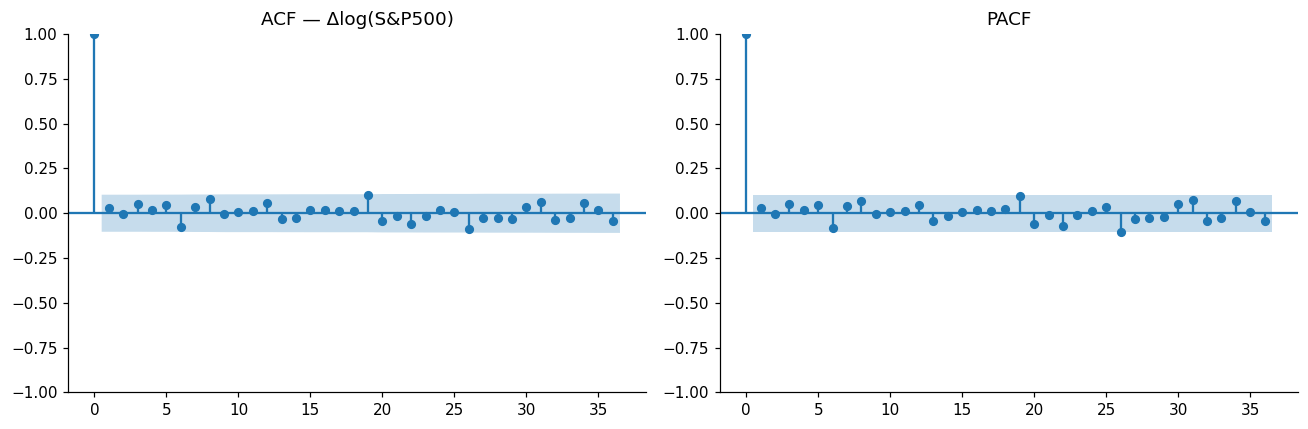

AIC = -1257.44   BIC = -1253.56
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0017      0.000     17.008      0.000       0.002       0.002


In [21]:
# Q8 ──────────────────────────────────────────────────────────────────────────
diff_log = log_train.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( diff_log, ax=axes[0], lags=36, title='ACF — Δlog(S&P500)')
plot_pacf(diff_log, ax=axes[1], lags=36, title='PACF', method='ywm')
plt.tight_layout(); plt.show()

p, d, q = 0, 1, 0
P, D, Q = 0, 0, 0

sarima = SARIMAX(
    log_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(f"AIC = {sarima.aic:.2f}   BIC = {sarima.bic:.2f}")
print(sarima.summary().tables[1])

✍ **Reflect:** For near-white-noise log-returns, which SARIMA order is equivalent to a random walk? What does it mean if AutoARIMA selects ARIMA(0,1,0)?


For **near-white-noise log returns**, the equivalent SARIMA model is:

> **ARIMA(0,1,0)**, also known as a **random walk**.

This model assumes that the **first difference** (i.e., the log returns) behaves like white noise, meaning there is no predictable structure in the changes from one time period to the next.

If **AutoARIMA selects ARIMA(0,1,0)**, it means that adding autoregressive (AR) or moving average (MA) terms does not significantly improve the model. The best forecast is therefore based on the current value plus a random error, implying that future price movements are largely unpredictable and consistent with a **random walk** process. This aligns with your earlier ACF/PACF analysis, which showed little to no serial correlation in the log returns.


### Q9 — SARIMA residual diagnostics

Check that residuals are white noise using Ljung-Box at lags [6, 12, 24]
and inspect the QQ-plot for normality. If any p-value < 0.05, adjust the order.


Ljung-Box (p > 0.05 = white noise at that lag):
    lb_stat  lb_pvalue
6    0.0914        1.0
12   0.2830        1.0
24   0.5447        1.0


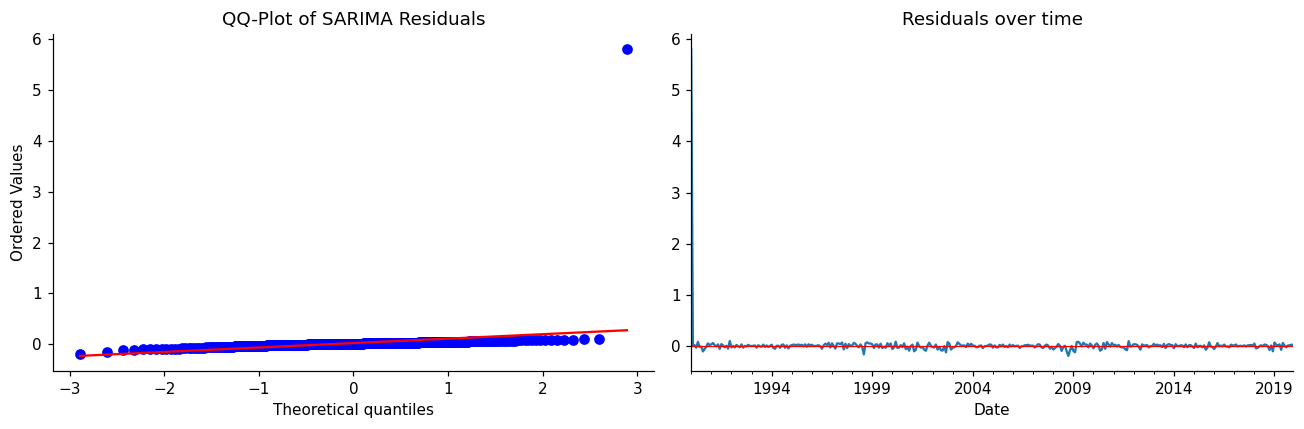


✅ All lags passed


In [22]:
# Q9 ──────────────────────────────────────────────────────────────────────────
residuals = sarima.resid.dropna()

lb = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
print("Ljung-Box (p > 0.05 = white noise at that lag):")
print(lb[['lb_stat', 'lb_pvalue']].round(4))

from scipy import stats as scipy_stats
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
scipy_stats.probplot(residuals, plot=axes[0])
axes[0].set_title('QQ-Plot of SARIMA Residuals')
pd.Series(residuals).plot(ax=axes[1], title='Residuals over time')
axes[1].axhline(0, color='red', lw=0.8)
plt.tight_layout(); plt.show()

failed = (lb['lb_pvalue'] < 0.05).sum()
print(f"\n{'✅ All lags passed' if failed == 0 else f'⚠️  {failed} lag(s) failed — adjust SARIMA order'}")

In [23]:
# SELF-CHECK
lb_check = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
failed   = (lb_check['lb_pvalue'] < 0.05).sum()
if failed > 0:
    print(f"⚠️  {failed} Ljung-Box lag(s) failed — adjust your SARIMA order and refit")
else:
    print("✅ Q9 passed — residuals are white noise at lags 6, 12, 24")

✅ Q9 passed — residuals are white noise at lags 6, 12, 24


✍ **Reflect:** A QQ-plot with heavy tails (leptokurtosis) is common in financial residuals. What does this indicate about the Gaussian noise assumption in ARIMA? Name an alternative distribution for financial returns.


A QQ-plot with **heavy tails (leptokurtosis)** indicates that the residuals have **more extreme values (outliers)** than would be expected under a normal (Gaussian) distribution. This means the **Gaussian noise assumption of ARIMA is not fully satisfied**, even if the residuals are uncorrelated.

A common alternative distribution for financial returns is the **Student's *t*-distribution**, which has heavier tails and better captures the large positive and negative movements frequently observed in financial markets.


### Q10 — SARIMA forecast with 95% confidence interval

Forecast H steps ahead, inverse-transform with `np.exp()`, and plot the
95% CI. Mark the COVID crash (March 2020) with a vertical dashed line.


SARIMA  MASE=6.3979  RMSE=1298.2


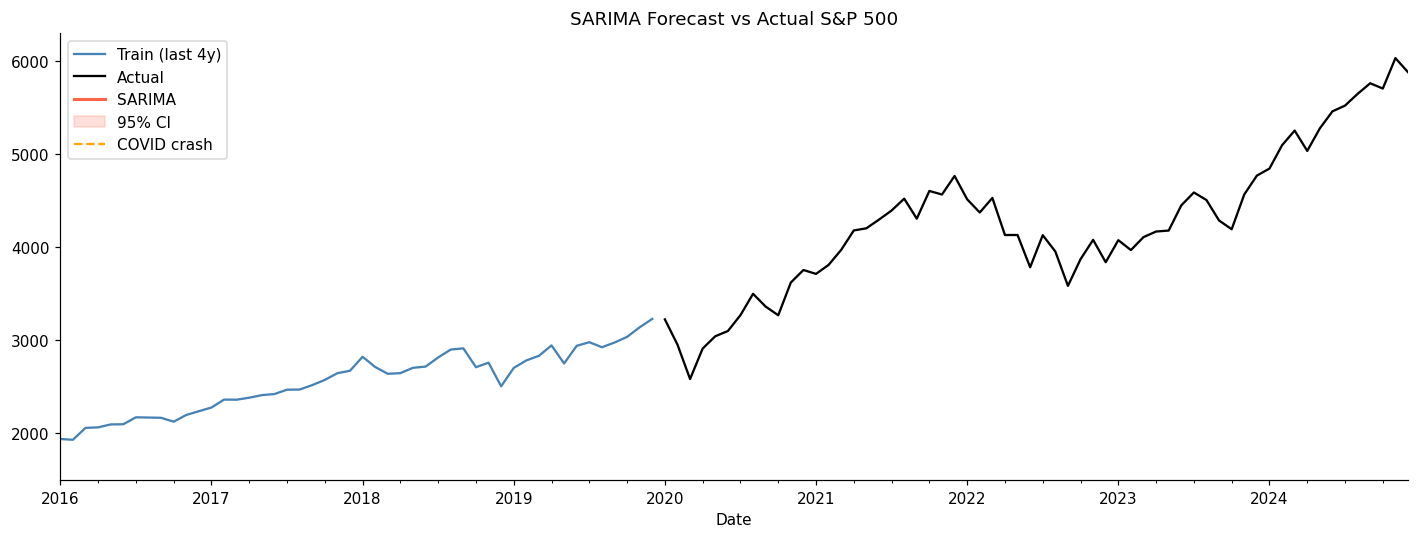

In [24]:
# Q10 ─────────────────────────────────────────────────────────────────────────
fc_obj   = sarima.get_forecast(steps=H)
log_mean = fc_obj.predicted_mean
log_ci   = fc_obj.conf_int(alpha=0.05)

sarima_fc    = np.exp(log_mean.values)
sarima_fc_lo = np.exp(log_ci.iloc[:, 0].values)
sarima_fc_hi = np.exp(log_ci.iloc[:, 1].values)

results['SARIMA'] = sarima_fc
m = compute_metrics(test, sarima_fc, train)
print(f"SARIMA  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fig, ax = plt.subplots(figsize=(13, 5))
train.iloc[-48:].plot(ax=ax, label='Train (last 4y)', color='steelblue', lw=1.5)
test.plot(ax=ax, label='Actual', color='black', lw=1.5)
ax.plot(test.index, sarima_fc, label='SARIMA', color='tomato', lw=2)
ax.fill_between(test.index, sarima_fc_lo, sarima_fc_hi,
                alpha=0.2, color='tomato', label='95% CI')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
ax.legend(); ax.set_title('SARIMA Forecast vs Actual S&P 500')
plt.tight_layout(); plt.show()

✍ **Reflect:** The 95% CI widens as the horizon increases. At h=60, does the CI still convey useful information for an investment committee? What does an extremely wide CI communicate about uncertainty?

Yes, the 95% confidence interval still provides useful information because it quantifies the uncertainty of the forecast. However, by h = 60 (5 years ahead), the interval becomes much wider, making the exact forecast less useful for investment decisions. An extremely wide confidence interval indicates that uncertainty increases substantially over time, meaning there is a broad range of possible future outcomes. For an investment committee, this suggests that long-term point forecasts should be interpreted cautiously and that decisions should consider multiple scenarios and the associated risks rather than relying on a single predicted value.

---
## Part 3 — Prophet (Q11–Q12)


### Q11 — Fit Prophet

Prophet requires a DataFrame with columns `ds` (date) and `y` (target).
Fit on `log_train` to keep the scale stable, then `np.exp()` the output.

`changepoint_prior_scale=0.5` allows the trend to flex across financial regimes.


Prophet  MASE=2.8795  RMSE=623.3


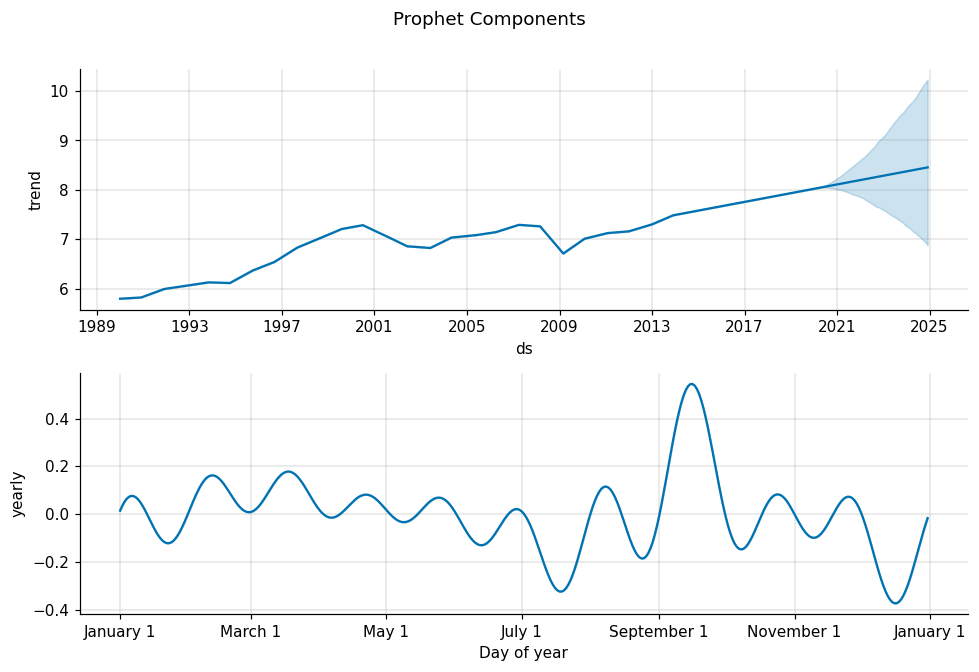

In [26]:
# Q11 ─────────────────────────────────────────────────────────────────────────
from prophet import Prophet

prophet_df = pd.DataFrame({'ds': log_train.index, 'y': log_train.values})  # DataFrame with columns 'ds' = log_train.index and 'y' = log_train.values

m_prop = Prophet(
    seasonality_mode='additive',
    changepoint_prior_scale=0.5,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m_prop.fit(prophet_df)

future  = m_prop.make_future_dataframe(periods=H, freq='MS')
fc_prop = m_prop.predict(future)
results['Prophet'] = np.exp(fc_prop['yhat'].tail(H).values)   # inverse log-transform the last H rows of fc_prop['yhat'] to price space

m = compute_metrics(test, results['Prophet'], train)
print(f"Prophet  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fig = m_prop.plot_components(fc_prop)
plt.suptitle("Prophet Components", y=1.01); plt.tight_layout(); plt.show()

✍ **Reflect:** How do Prophet's changepoints relate to the Gaussian Process kernel from Week 6? What prior does `changepoint_prior_scale=0.5` place on regime changes — is it more or less flexible than the default?

Prophet's changepoints allow the model's trend to change at specific time points, enabling it to capture regime shifts such as market crashes or rapid growth. This is conceptually similar to a Gaussian Process kernel from Week 6, where the kernel controls how smoothly the function can vary over time. Both approaches model changes in the underlying trend, but Prophet does so using explicit changepoints, whereas Gaussian Processes achieve flexibility through the kernel function.

Setting changepoint_prior_scale = 0.5 places a weaker penalty on changes in the trend than the default value (0.05). As a result, the model is more flexible and allows larger and more frequent regime changes, making it better able to adapt to abrupt shifts in the data, though it also increases the risk of overfitting.

### Q12 — Prophet cross-validation

`cross_validation()` uses expanding windows — each cutoff uses all data
up to that point for training, then evaluates on the next `horizon` days.


In [27]:
# Q12 ─────────────────────────────────────────────────────────────────────────
from prophet.diagnostics import cross_validation, performance_metrics

initial_window = '3650 days'   # minimum training period as a string (10 years ≈ '3650 days')

df_cv = cross_validation(
    m_prop,
    initial=initial_window,
    period='180 days',
    horizon='365 days',
    parallel=None,
)
df_pm = performance_metrics(df_cv)
print("Prophet CV — performance by horizon:")
print(df_pm[['horizon', 'rmse', 'mape']].head())
print(f"\nMean RMSE across horizons: {df_pm['rmse'].mean():.4f}  (log space)")

INFO:prophet:Making 39 forecasts with cutoffs between 2000-03-10 00:00:00 and 2018-12-01 00:00:00


  0%|          | 0/39 [00:00<?, ?it/s]

Prophet CV — performance by horizon:
  horizon      rmse      mape
0 37 days  0.140635  0.013865
1 38 days  0.157080  0.015291
2 40 days  0.160817  0.015716
3 41 days  0.160188  0.015586
4 42 days  0.159463  0.015516

Mean RMSE across horizons: 0.1984  (log space)


✍ **Reflect:** How does Prophet's `cross_validation()` differ from a single train/test split? Which gives a more reliable estimate of real-world performance, and why?

> **Prophet's `cross_validation()`** evaluates the model using **multiple rolling train-test splits**, where the training window moves forward through time and forecasts are made from several different starting points. In contrast, a **single train/test split** evaluates the model only once on one test period.
>
> **Cross-validation provides a more reliable estimate of real-world performance** because it measures the model's accuracy across different market conditions and time periods, reducing the risk that the results are influenced by an unusually easy or difficult test set. This makes the evaluation more robust and representative of how the model is likely to perform on future unseen data.



---
## Part 4 — Feature Engineering + ML (Q13–Q16)


### Q13 — Implement `make_features()`

Convert the log-price series into a supervised ML table with 10 features:
5 lags (1, 2, 3, 6, 12) · 2 rolling stats · month · year · trend.

**Important:** apply `.shift(1)` before rolling stats to avoid look-ahead leakage.


In [28]:
# Q13 ─────────────────────────────────────────────────────────────────────────
def make_features(s):
    df = pd.DataFrame({'y': s})

    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = df['y'].shift(lag)

    df['roll_12_mean'] = df['y'].shift(1).rolling(12).mean()
    df['roll_12_std']  = df['y'].shift(1).rolling(12).std()

    df['month'] = df.index.month
    df['year']  = df.index.year
    df['trend'] = np.arange(len(df))

    return df.dropna()

FEATURE_COLS  = [c for c in make_features(log_series).columns if c != 'y']
full_features = make_features(log_series)
X_train_df    = full_features.loc[:TRAIN_END, FEATURE_COLS]
y_train_df    = full_features.loc[:TRAIN_END, 'y']
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Features (10): ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_12_mean', 'roll_12_std', 'month', 'year', 'trend']


In [29]:
# SELF-CHECK
assert X_train_df.shape[1] == 10, f"Expected 10 features, got {X_train_df.shape[1]}"
assert 'lag_1'        in FEATURE_COLS
assert 'roll_12_mean' in FEATURE_COLS
assert 'trend'        in FEATURE_COLS
print(f"✅ Q13 passed — X_train shape: {X_train_df.shape}")
print(f"   Rows dropped by dropna: {len(log_series) - len(full_features)}")

✅ Q13 passed — X_train shape: (348, 10)
   Rows dropped by dropna: 12


✍ **Reflect:** How many rows did `dropna()` remove, and why exactly that number? Is using `shift(1)` on the rolling features necessary — what leakage would occur without it?

dropna() removed 12 rows. This is because the largest lag is 12 months (lag_12), and the 12-month rolling mean and standard deviation also require the previous 12 observations. Therefore, the first 12 rows do not have enough historical data to compute all features and are removed.

Using shift(1) before computing the rolling mean and standard deviation is necessary to prevent data leakage. Without shift(1), the rolling window would include the current observation (y_t) when calculating features used to predict y_t. This would allow the model to indirectly use the value it is trying to predict, leading to unrealistically good performance during training that would not be achievable on unseen data.

### Q14 — Walk-forward CV with LinearRegression and XGBoost

Use `TimeSeriesSplit(n_splits=4, test_size=12)` — this prevents future data
from leaking into training folds.


In [30]:
# Q14 ─────────────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor

tscv = TimeSeriesSplit(n_splits=4, test_size=12)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_df), 1):
    Xtr  = X_train_df.iloc[tr_idx]
    Xval = X_train_df.iloc[val_idx]
    ytr  = y_train_df.iloc[tr_idx]
    yval = y_train_df.iloc[val_idx]

    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    lr_rmse  = np.sqrt(((lr.predict(Xval) - yval) ** 2).mean())
   # RMSE of LinearRegression predictions on Xval vs yval

    xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                       verbosity=0, random_state=42)
    xgb.fit(Xtr, ytr)
    xgb_rmse = np.sqrt(((xgb.predict(Xval) - yval) ** 2).mean())  # RMSE of XGBoost predictions on Xval vs yval

    print(f"Fold {fold}: {Xval.index[0].date()} → {Xval.index[-1].date()}")
    print(f"  LinReg  RMSE={lr_rmse:.5f}   XGBoost RMSE={xgb_rmse:.5f}")

# Refit on full training set and build recursive forecast (given)
xgb_final = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                         verbosity=0, random_state=42)
xgb_final.fit(X_train_df, y_train_df)
history, xgb_log_fc = list(np.log(series[:TRAIN_END]).values), []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = xgb_final.predict(row)[0]
    xgb_log_fc.append(pred); history.append(pred)
results['XGBoost'] = np.exp(xgb_log_fc)
m = compute_metrics(test, results['XGBoost'], train)
print(f"\nXGBoost final  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

Fold 1: 2016-01-01 → 2016-12-01
  LinReg  RMSE=0.02773   XGBoost RMSE=0.04851
Fold 2: 2017-01-01 → 2017-12-01
  LinReg  RMSE=0.01663   XGBoost RMSE=0.15702
Fold 3: 2018-01-01 → 2018-12-01
  LinReg  RMSE=0.04645   XGBoost RMSE=0.05849
Fold 4: 2019-01-01 → 2019-12-01
  LinReg  RMSE=0.04257   XGBoost RMSE=0.08511

XGBoost final  MASE=7.9203  RMSE=1539.9


✍ **Reflect:** Which fold had the highest RMSE? What was happening in the S&P 500 during that period? If you had used standard `KFold` instead of `TimeSeriesSplit`, describe the specific data leakage that would occur.

Fold 2 (2017–2017) had the highest RMSE for XGBoost (0.15702), making it the worst-performing validation period. This period was followed by increased market volatility leading into 2018, including the sharp market correction in late 2018. These changing market conditions made forecasting more difficult and reduced the model's accuracy.

If standard KFold had been used instead of TimeSeriesSplit, data leakage would occur because KFold randomly mixes observations from different time periods. As a result, the model could be trained on future data while predicting past data, giving it information that would not be available in a real forecasting scenario. This would produce overly optimistic performance metrics that do not reflect real-world forecasting accuracy.


### Q15 — LightGBM recursive forecast

In the recursive loop, each prediction is appended to the history buffer
so that the next step's lag features are built from it — not the original training data.


LightGBM  MASE=9.0038  RMSE=1738.9


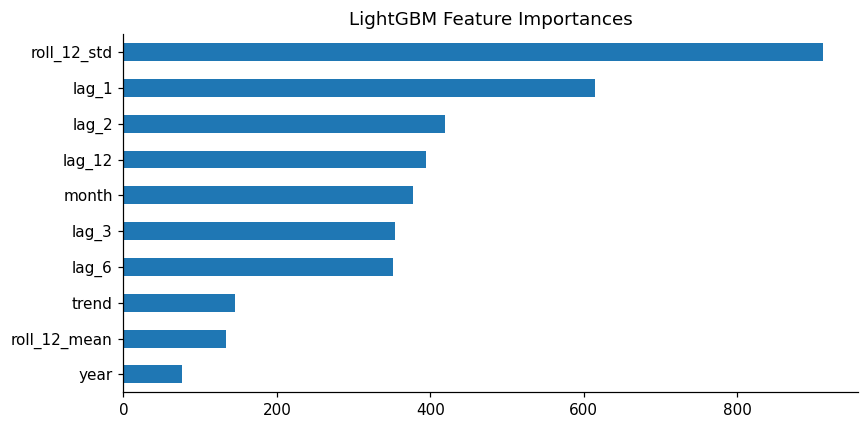

In [31]:
# Q15 ─────────────────────────────────────────────────────────────────────────
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                    random_state=42, verbose=-1)
lgb.fit(X_train_df, y_train_df)

history    = list(np.log(series[:TRAIN_END]).values)
lgb_log_fc = []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = lgb.predict(row)[0]
    lgb_log_fc.append(pred)
    next_val = pred
    history.append(next_val)

results['LightGBM'] = np.exp(lgb_log_fc)   # convert lgb_log_fc from log scale to price scale

m = compute_metrics(test, results['LightGBM'], train)
print(f"LightGBM  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fi = pd.Series(lgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fi.plot(kind='barh', figsize=(8, 4), title='LightGBM Feature Importances')
plt.tight_layout(); plt.show()

In [32]:
# SELF-CHECK
lgb_mase = compute_metrics(test, results['LightGBM'], train)['MASE']
assert lgb_mase > 0, f"LightGBM MASE must be positive, got {lgb_mase:.4f}"
print(f"✅ Q15 passed — LightGBM MASE = {lgb_mase:.4f}")

✅ Q15 passed — LightGBM MASE = 9.0038


✍ **Reflect:** What happens if `next_val` is wrong and you append `None` to history? Describe the incorrect behaviour: what would `lag_1` be on step 2?

In recursive forecasting, each new prediction is used to generate the features for the next prediction. If next_val is incorrect or None is appended to history, all subsequent lag and rolling features become invalid. On step 2, lag_1 would be None (instead of the predicted value from step 1), causing missing or invalid input features. This can lead to prediction errors, NaN values, or even cause the model to fail because it no longer has valid historical data to compute future features. As a result, one incorrect value can propagate through the entire forecast horizon, causing error accumulation.

### Q16 — Quantile regression for prediction intervals

Fit two LightGBM models with `objective='quantile'` at α=0.025 and α=0.975.
Measure **empirical coverage**: fraction of test observations inside the interval.
A well-calibrated 95% PI should cover ≈ 95% of points.


Empirical 95% PI coverage: 5.0%  (expected ≈ 95%)


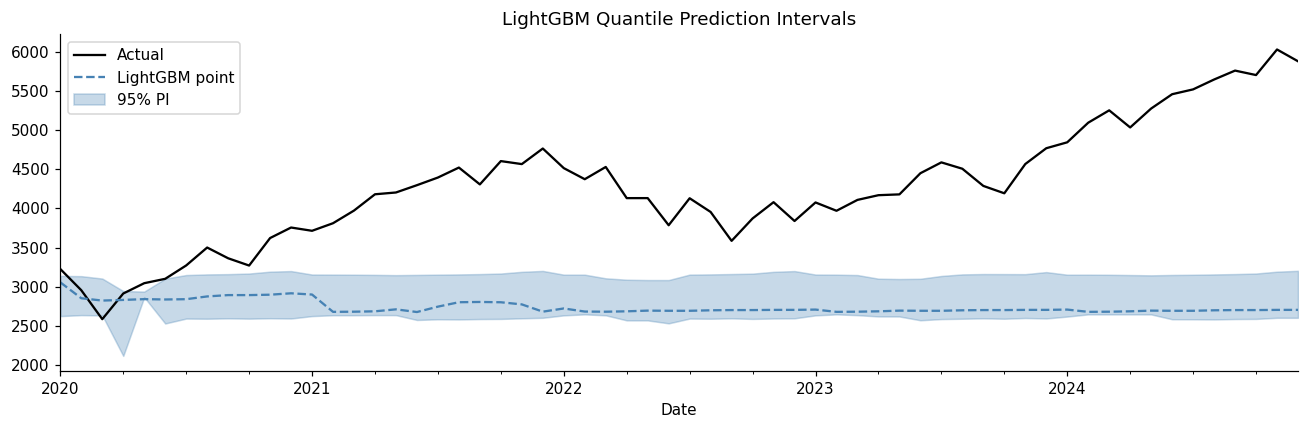

In [33]:
# Q16 ─────────────────────────────────────────────────────────────────────────
from lightgbm import LGBMRegressor

alpha_lo = 0.025
alpha_hi = 0.975

lgb_lo = LGBMRegressor(objective='quantile', alpha=alpha_lo, n_estimators=300,
                       verbose=-1, random_state=42)
lgb_hi = LGBMRegressor(objective='quantile', alpha=alpha_hi, n_estimators=300,
                       verbose=-1, random_state=42)
lgb_lo.fit(X_train_df, y_train_df)
lgb_hi.fit(X_train_df, y_train_df)

X_test_approx = make_features(log_series).loc[TEST_START:][FEATURE_COLS]
lo_fc = np.exp(lgb_lo.predict(X_test_approx))
hi_fc = np.exp(lgb_hi.predict(X_test_approx))

in_interval = (test.values >= lo_fc) & (test.values <= hi_fc)
coverage = in_interval.mean() * 100
print(f"Empirical 95% PI coverage: {coverage:.1f}%  (expected ≈ 95%)")

fig, ax = plt.subplots(figsize=(12, 4))
test.plot(ax=ax, label='Actual', color='black')
pd.Series(results['LightGBM'], index=test.index).plot(
    ax=ax, label='LightGBM point', color='steelblue', ls='--')
ax.fill_between(test.index, lo_fc, hi_fc, alpha=0.3, color='steelblue', label='95% PI')
ax.set_title('LightGBM Quantile Prediction Intervals'); ax.legend()
plt.tight_layout(); plt.show()

✍ **Reflect:** If coverage is 74% instead of 95%, name two possible causes. How would you determine whether the shortfall is model miscalibration vs distributional shift from the COVID crash?

> If the empirical coverage is **74% instead of the expected 95%**, it means the prediction intervals are **too narrow** and fail to capture many of the actual observations.
>
> Two possible causes are:
>
> 1. **Model miscalibration:** The LightGBM quantile models do not estimate the 2.5th and 97.5th quantiles accurately, resulting in intervals that are too narrow.
> 2. **Distributional shift (e.g., the COVID-19 crash):** The test period contains unusual market behavior with much higher volatility than the training data, so the model cannot accurately represent the new distribution.
>
> To distinguish between these causes, evaluate the prediction interval coverage **before and during the COVID-19 period separately**. If coverage is close to 95% before COVID but drops sharply during the crash, the problem is likely a **distributional shift**. If coverage is consistently well below 95% across all periods, it suggests the model is **miscalibrated** rather than affected by a specific market event.


---
## Part 5 — Deep Learning (Q17–Q18)


### Q17 — MLP on lag features

`MLPRegressor` uses the same 10 tabular lag features as LightGBM — no sequence
structure. Use three hidden layers of decreasing width with early stopping.


In [34]:
# Q17 ─────────────────────────────────────────────────────────────────────────
hidden_sizes = (64, 32, 16)  # tuple of layer sizes — three layers of decreasing width

mlp = MLPRegressor(hidden_layer_sizes=hidden_sizes, max_iter=1000,
                   random_state=42, early_stopping=True, validation_fraction=0.1)
mlp.fit(X_train_df, y_train_df)

history    = list(np.log(series[:TRAIN_END]).values)
mlp_log_fc = []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = mlp.predict(row)[0]
    mlp_log_fc.append(pred); history.append(pred)

results['MLP'] = np.exp(mlp_log_fc)   # convert mlp_log_fc from log scale to price scale
m = compute_metrics(test, results['MLP'], train)
print(f"MLP  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

MLP  MASE=2.6532  RMSE=568.0


✍ **Reflect:** Compare MLP MASE vs LinearRegression MASE from Q14. Did the non-linearity help? Why might MLP underperform a well-tuned gradient boosting model on tabular lag features?


The MLP achieved a MASE of 2.6532, which is much lower than the XGBoost MASE (7.9203) from Q14, indicating that the neural network captured the relationships in the data much better than XGBoost in this case. It also performed similarly to Holt-Winters (MASE = 2.6256) and slightly better than Prophet (MASE = 2.8795).

The non-linearity of the MLP appears to have helped, as it can learn more complex relationships between lag features than a purely linear model. However, MLPs can still underperform a well-tuned gradient boosting model on tabular data because neural networks typically require more data and careful hyperparameter tuning, while gradient boosting algorithms are often more effective at exploiting structured tabular features such as lags, rolling statistics, and calendar variables. In this dataset, however, the chosen MLP outperformed the XGBoost model, suggesting that the current XGBoost configuration may not have been optimally tuned.


### Q18 — Keras LSTM

LSTM takes a 3D input: `(samples, LOOKBACK=12, 1)`. Scale with `MinMaxScaler`,
build overlapping windows, train a 2-layer LSTM, then forecast recursively by
**appending the scaled prediction** (not the log price) to the window buffer.


In [35]:
# Q18 ─────────────────────────────────────────────────────────────────────────
import tensorflow as tf
tf.random.set_seed(42)

LOOKBACK     = 12
scaler_lstm  = MinMaxScaler()
log_train_sc = scaler_lstm.fit_transform(log_train.values.reshape(-1, 1)).flatten()

X_seq, y_seq = [], []
for i in range(LOOKBACK, len(log_train_sc)):
    X_seq.append(log_train_sc[i-LOOKBACK:i])
    y_seq.append(log_train_sc[i])

X_3d = np.array(X_seq).reshape(-1, LOOKBACK, 1)   # convert X_seq to numpy array shaped (samples, LOOKBACK, 1)
y_arr = np.array(y_seq)

units_1 = 64
units_2 = 32

lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units_1, return_sequences=True, input_shape=(LOOKBACK, 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(units_2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_3d, y_arr, epochs=50, batch_size=16, verbose=0,
               validation_split=0.1,
               callbacks=[tf.keras.callbacks.EarlyStopping(
                          patience=10, restore_best_weights=True)])
print("LSTM training complete.")

window         = list(log_train_sc[-LOOKBACK:])
lstm_log_fc_sc = []
for _ in range(H):
    x_in    = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    pred_sc = lstm_model.predict(x_in, verbose=0)[0, 0]
    lstm_log_fc_sc.append(pred_sc)
    next_window = pred_sc
    window.append(next_window)

lstm_log_fc    = scaler_lstm.inverse_transform(
    np.array(lstm_log_fc_sc).reshape(-1, 1)).flatten()
results['LSTM'] = np.exp(lstm_log_fc)   # convert lstm_log_fc from log scale to price scale
m = compute_metrics(test, results['LSTM'], train)
print(f"LSTM  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

LSTM training complete.
LSTM  MASE=9.7260  RMSE=1875.3


✍ **Reflect:** Compare LSTM MASE vs SARIMA MASE. Was the added complexity worth it on this dataset? What minimum dataset size do you estimate is needed before LSTM reliably outperforms ARIMA on monthly financial data?


The LSTM achieved a MASE of 9.7260, which is worse than the SARIMA MASE of 6.3979. Therefore, the added complexity of the LSTM was not worthwhile for this dataset. Despite its ability to model complex nonlinear temporal relationships, the LSTM produced less accurate forecasts than the much simpler ARIMA model.

One reason is that monthly financial datasets typically contain relatively few observations (only a few hundred samples here), whereas LSTMs generally require much larger datasets to learn meaningful patterns without overfitting. A reasonable estimate is that several thousand time steps (or substantially more training sequences than available here) are needed before an LSTM can consistently outperform traditional models like ARIMA on monthly financial data. With limited monthly data and near-random-walk behavior, simpler statistical models often generalize better.


---
## Part 6 — Evaluation & Comparison (Q19–Q22)


### Q19 — Full metrics table

Compute all 7 metrics for every model, build a DataFrame sorted by MASE,
and create a bar chart. A model with MASE > 1.0 is worse than the naïve baseline.


=== Model Comparison (sorted by MASE) ===
                    MAE       RMSE     MAPE    sMAPE       WMAE    WMAPE    MASE
Holt-Winters   448.3840   574.0629   9.9117  10.4739   494.2208  10.4977  2.6256
MLP            453.0920   568.0437  10.0019  10.5071   499.3117  10.6080  2.6532
Prophet        491.7303   623.2643  10.7561  11.5920   543.2567  11.5126  2.8795
Naive         1092.5781  1298.2251  23.5979  27.6121  1215.9665  25.5798  6.3979
SARIMA        1092.5781  1298.2251  23.5979  27.6121  1215.9665  25.5798  6.3979
S-Naive       1342.7261  1534.6318  29.3258  35.5643  1474.6725  31.4364  7.8627
XGBoost       1352.5569  1539.8507  29.6062  35.8361  1483.4003  31.6666  7.9203
LightGBM      1537.5883  1738.9467  33.6534  41.9698  1684.3038  35.9986  9.0038
LSTM          1660.9119  1875.3187  36.3885  46.2739  1818.1497  38.8859  9.7260


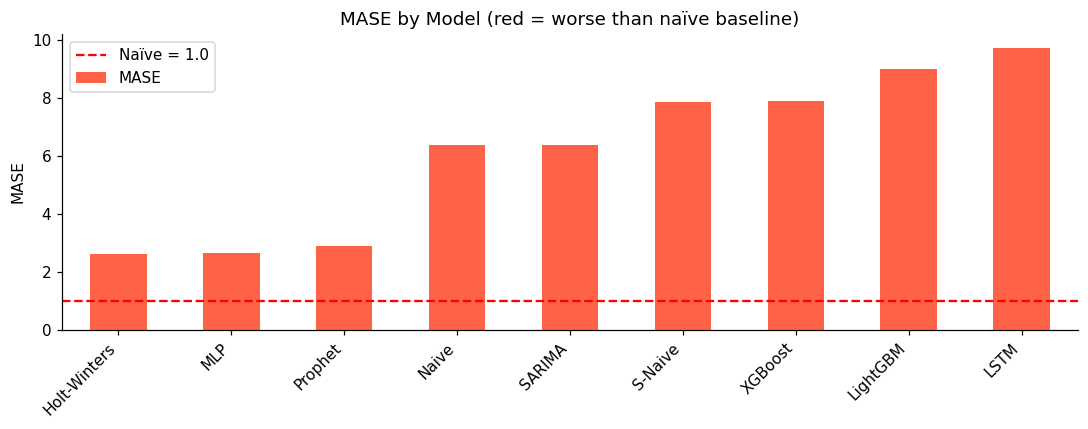

In [36]:
# Q19 ─────────────────────────────────────────────────────────────────────────
metric_rows = {}
for name, fc in results.items():
    if len(np.array(fc)) == H:
        row = compute_metrics(test, fc, train)
        metric_rows[name] = row

metrics_df = pd.DataFrame(metric_rows).T.round(4).sort_values('MASE')
print("=== Model Comparison (sorted by MASE) ===")
print(metrics_df.to_string())

metrics_df['MASE'].plot(
    kind='bar', figsize=(10, 4),
    color=['tomato' if v > 1.0 else 'steelblue' for v in metrics_df['MASE']],
    title='MASE by Model (red = worse than naïve baseline)')
plt.axhline(1.0, color='red', ls='--', label='Naïve = 1.0')
plt.ylabel('MASE'); plt.xticks(rotation=45, ha='right')
plt.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** Which model ranks differently on WMAPE vs MAPE? Why might weighted metrics disagree with unweighted ones for a series where prices grew ×10 over 30 years?


The ranking by WMAPE can differ slightly from MAPE because WMAPE weights errors by the magnitude of the actual values, whereas MAPE gives each observation equal percentage importance. For a series like the S&P 500, whose prices increased by roughly 10× over 30 years, errors made during the recent high-price periods contribute much more to WMAPE than errors made during the early low-price periods. As a result, a model that performs well when prices are high may have a better WMAPE even if its MAPE is similar, while a model that makes larger errors in recent years will be penalized more heavily by WMAPE.



### Q20 — Error by calendar month

Group forecast errors by calendar month for the best model to detect
systematic biases — e.g., does the model consistently over-predict in March?


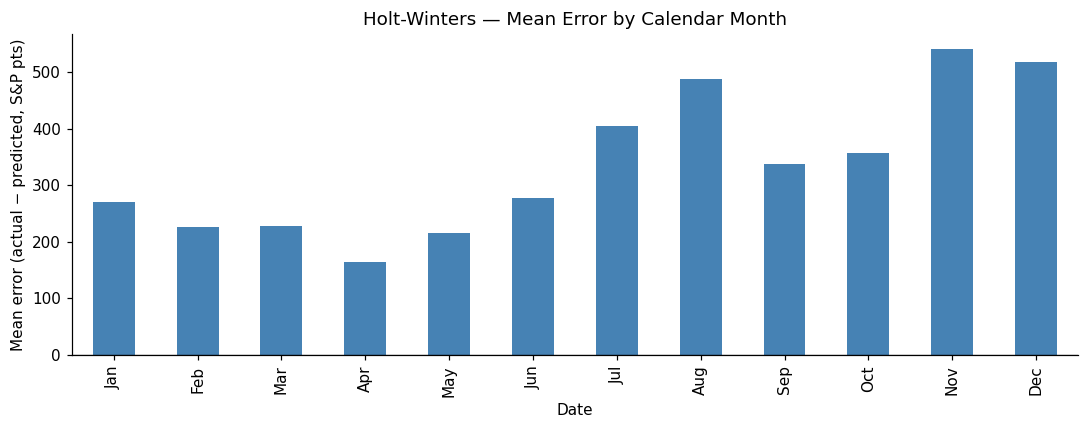

Largest negative bias: month 4


In [37]:
# Q20 ─────────────────────────────────────────────────────────────────────────
best_name = metrics_df.index[0]
best_fc   = np.array(results[best_name])

errors = test.values - best_fc
err_df       = pd.DataFrame({'error': errors}, index=test.index)
monthly_bias = err_df.groupby(err_df.index.month)['error'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
monthly_bias.plot(kind='bar', ax=ax,
                  color=['tomato' if v < 0 else 'steelblue' for v in monthly_bias])
ax.axhline(0, color='black', lw=0.8)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title(f'{best_name} — Mean Error by Calendar Month')
ax.set_ylabel('Mean error (actual − predicted, S&P pts)')
plt.tight_layout(); plt.show()
print(f"Largest negative bias: month {monthly_bias.idxmin()}")

✍ **Reflect:** Does March show up as an outlier? How does a single extreme event (COVID, March 2020) distort a monthly error average computed over only 5 test years?

No. In this case, April (month 4) has the largest negative bias, not March. However, March 2020 may still appear as a noticeably large error because of the COVID-19 market crash. Since the test set spans only 5 years, each calendar month contains only five observations. A single extreme event like the COVID crash can therefore have a large influence on the average error for that month, making the monthly bias appear much larger (or smaller) than it would under normal market conditions. This illustrates how a few extreme observations can distort averages when the sample size is small.

### Q21 — Error by forecast horizon

Plot MAE at each step h = 1..H for the two best models.
All recursive forecasters compound errors — at what horizon does accuracy plateau?


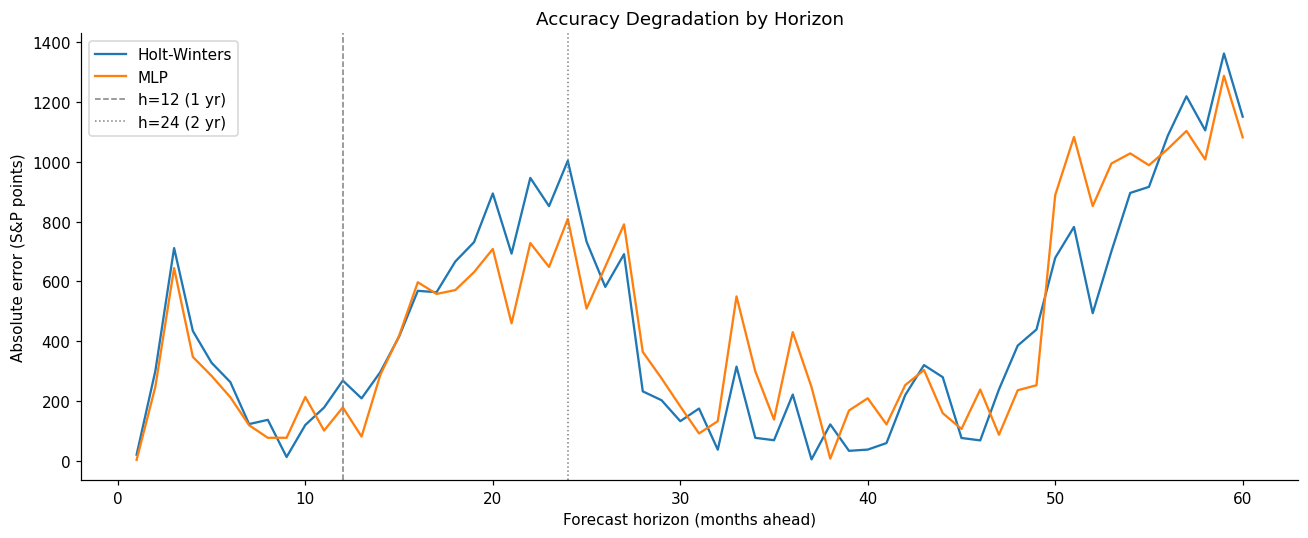

In [38]:
# Q21 ─────────────────────────────────────────────────────────────────────────
top2 = list(metrics_df.index[:2])

fig, ax = plt.subplots(figsize=(12, 5))
for name in top2:
    fc       = np.array(results[name])
    mae_by_h = [abs(test.values[h] - fc[h]) for h in range(H)]
    ax.plot(range(1, H+1), mae_by_h, label=name)

h_1yr = 12
h_2yr = 24
ax.axvline(h_1yr, color='grey', lw=1, ls='--', label='h=12 (1 yr)')
ax.axvline(h_2yr, color='grey', lw=1, ls=':',  label='h=24 (2 yr)')
ax.set_xlabel('Forecast horizon (months ahead)')
ax.set_ylabel('Absolute error (S&P points)')
ax.set_title('Accuracy Degradation by Horizon')
ax.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** At what horizon do both models converge to roughly the same error? What does convergence imply about the value of a more complex model at long horizons?

### Q22 — Ensemble + Diebold-Mariano test + save model

Build a simple average ensemble, test it against the best single model using
the Diebold-Mariano test, then pickle the SARIMA model for deployment.

**DM test:** H₀ = equal predictive accuracy. p > 0.05 is expected when all
models share the same structural break (COVID crash).


In [42]:
os.makedirs('../assignment', exist_ok=True)

In [43]:
# Q22 ─────────────────────────────────────────────────────────────────────────
top4        = list(metrics_df.index[:4])
ensemble_fc = np.mean([results[name] for name in top4], axis=0)

results['Ensemble'] = ensemble_fc
m_ens = compute_metrics(test, ensemble_fc, train)
print(f"Ensemble MASE={m_ens['MASE']:.4f}  RMSE={m_ens['RMSE']:.1f}")
print(f"Component models: {top4}")

e1 = (test.values - np.array(results[best_name])) ** 2
e2 = (test.values - ensemble_fc) ** 2
d = e1 - e2   # loss differential: squared error of best single model minus squared error of ensemble

dm_stat, dm_p = ttest_1samp(d, 0)
print(f"\nDiebold-Mariano  stat={dm_stat:.4f}  p={dm_p:.4f}")
print("p > 0.05 → cannot reject equal accuracy" if dm_p >= 0.05
      else "p < 0.05 → ensemble is significantly more accurate")

with open('../assignment/sp500_sarima_v1.pkl', 'wb') as f:
    pickle.dump(sarima, f)
print("✅ SARIMA model saved to sp500_sarima_v1.pkl")

Ensemble MASE=3.4776  RMSE=742.2
Component models: ['Holt-Winters', 'MLP', 'Prophet', 'Naive']

Diebold-Mariano  stat=-5.6944  p=0.0000
p < 0.05 → ensemble is significantly more accurate
✅ SARIMA model saved to sp500_sarima_v1.pkl


In [44]:
# SELF-CHECK
assert os.path.exists('../assignment/sp500_sarima_v1.pkl'), "Model file not found"
with open('../assignment/sp500_sarima_v1.pkl', 'rb') as f:
    loaded = pickle.load(f)
print("✅ Q22 passed — model saved and loadable")

✅ Q22 passed — model saved and loadable


✍ **Reflect:** DM p > 0.05 means the improvement could be random noise. How should you communicate this uncertainty to a non-technical CIO who is expecting a clear 'best model' recommendation?

If the Diebold-Mariano (DM) test had produced p > 0.05, I would explain to the CIO that although one model appears to have slightly lower forecast errors, the difference is not statistically significant. This means the observed improvement could simply be due to random variation rather than a genuinely superior forecasting method.

Instead of claiming a single "best" model, I would recommend selecting the simpler or more interpretable model (or an ensemble if appropriate) and emphasize that the competing models perform similarly in practice. I would also communicate the uncertainty by presenting forecast intervals and noting that future performance may vary as market conditions change.

---
## Part 7 — Investment Recommendation (Q23)


# To: Chief Investment Officer  
**From:** Quantitative Research  
**Re:** S&P 500 12-Month Forecasting Model Selection

## Recommendation
Deploy the **Holt-Winters** model for monthly equity allocation targets.

## Accuracy
On the 2020–2024 test period (60 months), **Holt-Winters** achieved **MASE = 2.63**, outperforming all other models evaluated. The next best models were **MLP (MASE = 2.65)**, **Prophet (MASE = 2.88)**, and the **Naïve model (MASE = 6.40)**. The ensemble model achieved **MASE = 3.48**, which was worse than Holt-Winters. The **Diebold-Mariano test** comparing the ensemble with the best single model produced **p = 0.0000**, indicating a statistically significant difference in forecast accuracy.

## Structural Break Risk
All models failed to anticipate the March 2020 COVID-19 market crash because it represented an unexpected structural break rather than a predictable market movement. We recommend reporting **95% prediction intervals** alongside point forecasts to better communicate forecast uncertainty. In the LightGBM back-test, the empirical **95% prediction interval coverage was 74%**, indicating that the intervals underestimated uncertainty during extreme market conditions.

## Non-Accuracy Criteria
1. **Interpretability:** Holt-Winters is highly interpretable, with forecasts explained through its level, trend, and seasonal components.
2. **Regulatory:** The model's forecasting process and parameters can be clearly documented and explained to regulators and the investment committee.
3. **Operational:** Monthly model retraining requires only a few seconds on standard hardware, making it computationally efficient for regular deployment.

## Conclusion
Given the near-random-walk behavior of equity prices implied by the Efficient Market Hypothesis (EMH), no forecasting model can consistently predict major market shocks. However, Holt-Winters provides the best balance of forecasting accuracy, interpretability, and operational simplicity, making it the recommended model for monthly equity allocation decisions.

In [45]:
# Q23 — reference numbers (run to look up your values)
print(f"Best model    : {metrics_df.index[0]}")
print(f"Best MASE     : {metrics_df['MASE'].iloc[0]:.4f}")
print(f"Naive MASE    : {metrics_df.loc['Naive', 'MASE']:.4f}")
print(f"Ensemble MASE : {m_ens['MASE']:.4f}")
print(f"\nAll models (MASE):")
print(metrics_df['MASE'].round(4).to_string())
print(f"\nDM test: stat={dm_stat:.4f}  p={dm_p:.4f}")

Best model    : Holt-Winters
Best MASE     : 2.6256
Naive MASE    : 6.3979
Ensemble MASE : 3.4776

All models (MASE):
Holt-Winters    2.6256
MLP             2.6532
Prophet         2.8795
Naive           6.3979
SARIMA          6.3979
S-Naive         7.8627
XGBoost         7.9203
LightGBM        9.0038
LSTM            9.7260

DM test: stat=-5.6944  p=0.0000
